SUBASRI R 24BAD116

Upload the Rock-Paper-Scissors ZIP file:


Saving archive (3).zip to archive (3).zip

Uploaded: archive (3).zip
Dataset extracted successfully!

Dataset location:
/content/rps_dataset

Original Dataset:
rock : 726
paper : 712
scissors : 750

Small dataset created!
Total images: 600

Dataset Split:

 TRAIN
rock : 140
paper : 140
scissors : 140

 VALIDATION
rock : 30
paper : 30
scissors : 30

 TEST
rock : 30
paper : 30
scissors : 30


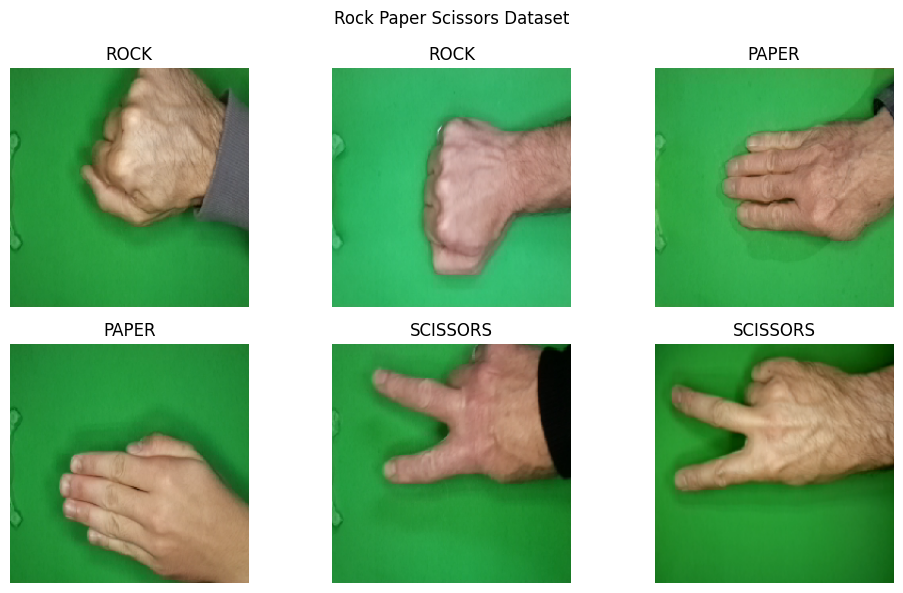

Found 420 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 90 images belonging to 3 classes.

Class Mapping:
{'paper': 0, 'rock': 1, 'scissors': 2}

Loading ResNet-50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

ResNet-50 model created!

Training ResNet-50...
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.3452 - loss: 1.2235 - val_accuracy: 0.3444 - val_loss: 1.0952
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.3143 - loss: 1.2281 - val_accuracy: 0.3333 - val_loss: 1.1011
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.3667 - loss: 1.1886 - val_accuracy: 0.3333 - val_loss: 1.1021
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.3190 - loss: 1.1855 - val_accuracy: 0.3556 - val_loss: 1.0914
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.3119 - loss: 1.1688 - val_accuracy: 0.3667 - val_loss: 1.0911
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3778 - loss: 1.0899

RESNE

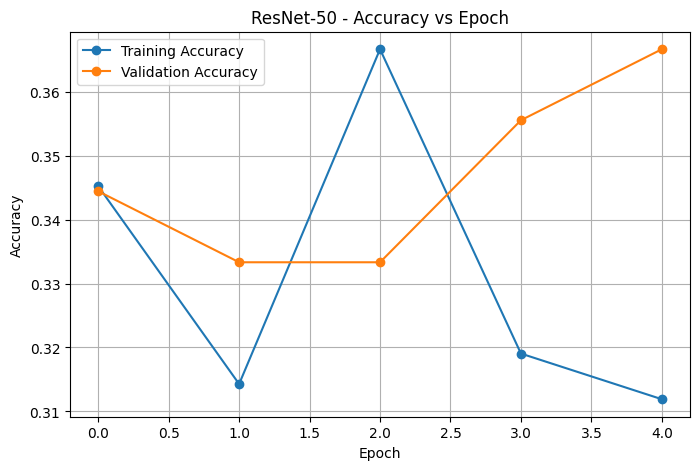

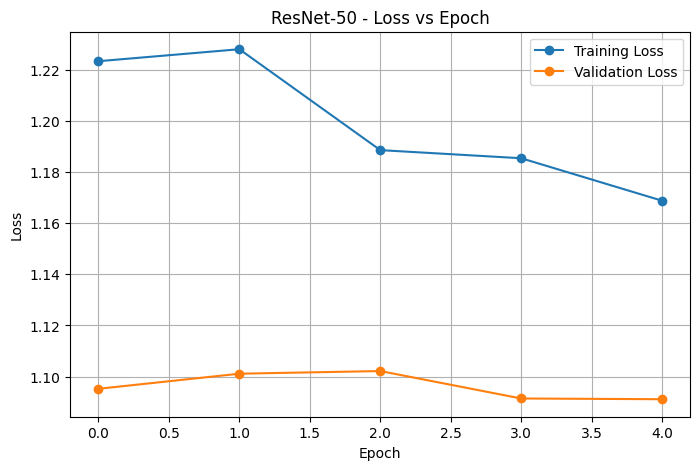


Starting Fine-Tuning...
Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.4833 - loss: 1.0332 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.7000 - loss: 0.8509 - val_accuracy: 0.3333 - val_loss: 1.1117
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.8048 - loss: 0.6786 - val_accuracy: 0.3333 - val_loss: 1.1198

Fine-Tuned Test Accuracy: 33.33 %

IMAGE PREDICTION
Actual: scissors
Predicted: paper
Confidence: 44.04 %


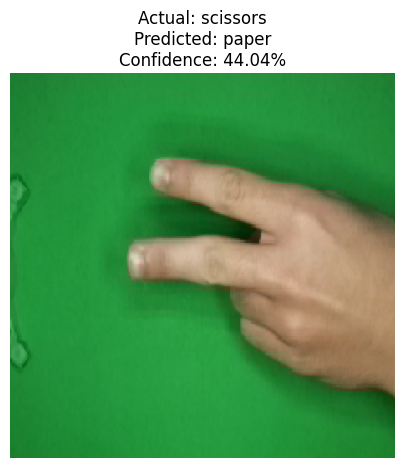


Model saved successfully!

FINAL RESULT
Initial ResNet-50 Test Accuracy : 37.78 %
Fine-Tuned ResNet-50 Accuracy   : 33.33 %

Experiment completed successfully!


In [2]:
!pip install -q transformers

import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


print("SUBASRI R 24BAD116")


print("\nUpload the Rock-Paper-Scissors ZIP file:")
uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("\nUploaded:", zip_file)


extract_path = "/content/rps_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall(extract_path)

print("Dataset extracted successfully!")




possible_paths = [
    extract_path,
    os.path.join(extract_path, "rps-cv-images")
]

DATA_PATH = None

for path in possible_paths:

    if os.path.exists(path):

        folders = set(os.listdir(path))

        if {"rock", "paper", "scissors"}.issubset(folders):
            DATA_PATH = path
            break

# Search recursively if necessary
if DATA_PATH is None:

    for root, dirs, files_in_folder in os.walk(extract_path):

        folders = set(dirs)

        if {"rock", "paper", "scissors"}.issubset(folders):
            DATA_PATH = root
            break

if DATA_PATH is None:
    raise Exception(
        "Could not find rock, paper and scissors folders. "
        "Please check that you downloaded the correct Kaggle dataset."
    )

print("\nDataset location:")
print(DATA_PATH)

# -------------------- COUNT ORIGINAL IMAGES --------------------
classes = ["rock", "paper", "scissors"]

print("\nOriginal Dataset:")

for class_name in classes:

    folder = os.path.join(DATA_PATH, class_name)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ]

    print(class_name, ":", len(images))


SMALL_DATASET = "/content/rps_small"

if os.path.exists(SMALL_DATASET):
    shutil.rmtree(SMALL_DATASET)

for split in ["train", "validation", "test"]:

    for class_name in classes:

        os.makedirs(
            os.path.join(
                SMALL_DATASET,
                split,
                class_name
            )
        )

random.seed(42)

for class_name in classes:

    source_folder = os.path.join(
        DATA_PATH,
        class_name
    )

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ]

    # Shuffle
    random.shuffle(images)

    # Only 200 images per class
    images = images[:200]

    # 70% = 140
    # 15% = 30
    # 15% = 30

    train_images = images[:140]
    validation_images = images[140:170]
    test_images = images[170:200]

    split_data = {
        "train": train_images,
        "validation": validation_images,
        "test": test_images
    }

    for split_name, split_images in split_data.items():

        for image_name in split_images:

            source = os.path.join(
                source_folder,
                image_name
            )

            destination = os.path.join(
                SMALL_DATASET,
                split_name,
                class_name,
                image_name
            )

            shutil.copy2(source, destination)

print("\nSmall dataset created!")
print("Total images: 600")


print("\nDataset Split:")

for split in ["train", "validation", "test"]:

    print("\n", split.upper())

    for class_name in classes:

        folder = os.path.join(
            SMALL_DATASET,
            split,
            class_name
        )

        count = len(os.listdir(folder))

        print(
            class_name,
            ":",
            count
        )


plt.figure(figsize=(10, 6))

sample_images = []

for class_name in classes:

    folder = os.path.join(
        SMALL_DATASET,
        "train",
        class_name
    )

    image_names = os.listdir(folder)[:2]

    for image_name in image_names:

        sample_images.append(
            (
                os.path.join(
                    folder,
                    image_name
                ),
                class_name
            )
        )

for i, (image_path, label) in enumerate(sample_images):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(label.upper())
    plt.axis("off")

plt.suptitle(
    "Rock Paper Scissors Dataset"
)

plt.tight_layout()
plt.show()



IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    os.path.join(
        SMALL_DATASET,
        "train"
    ),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_data = validation_datagen.flow_from_directory(
    os.path.join(
        SMALL_DATASET,
        "validation"
    ),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    os.path.join(
        SMALL_DATASET,
        "test"
    ),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass Mapping:")
print(train_data.class_indices)



print("\nLoading ResNet-50...")

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze feature extraction layers
base_model.trainable = False

# Add our own classifier
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

output = Dense(
    3,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("\nResNet-50 model created!")

# -------------------- COMPILE --------------------
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------- TRAIN --------------------
print("\nTraining ResNet-50...")

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)


test_loss, test_accuracy = model.evaluate(
    test_data,
    verbose=1
)

print("\n" + "=" * 60)
print("RESNET-50 RESULTS")
print("=" * 60)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ResNet-50 - Accuracy vs Epoch"
)

plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-50 - Loss vs Epoch"
)

plt.legend()
plt.grid(True)

plt.show()


print("\nStarting Fine-Tuning...")

base_model.trainable = True

# Freeze all except last 20 layers
for layer in base_model.layers[:-20]:

    layer.trainable = False

model.compile(
    optimizer=Adam(
        learning_rate=0.00001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=3
)

fine_loss, fine_accuracy = model.evaluate(
    test_data,
    verbose=0
)

print("\nFine-Tuned Test Accuracy:",
      round(fine_accuracy * 100, 2),
      "%")



class_names = [
    "paper",
    "rock",
    "scissors"
]

# Select random test image
random_class = random.choice(classes)

test_folder = os.path.join(
    SMALL_DATASET,
    "test",
    random_class
)

random_image = random.choice(
    os.listdir(test_folder)
)

image_path = os.path.join(
    test_folder,
    random_image
)

image = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = image_array / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(
    image_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction
)

predicted_class = class_names[
    predicted_index
]

confidence = prediction[
    0,
    predicted_index
]

print("\n" + "=" * 60)
print("IMAGE PREDICTION")
print("=" * 60)

print(
    "Actual:",
    random_class
)

print(
    "Predicted:",
    predicted_class
)

print(
    "Confidence:",
    round(
        float(confidence) * 100,
        2
    ),
    "%"
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Actual: {random_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()



model.save(
    "/content/rock_paper_scissors_resnet50.keras"
)

print("\nModel saved successfully!")


print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print(
    "Initial ResNet-50 Test Accuracy :",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Fine-Tuned ResNet-50 Accuracy   :",
    round(fine_accuracy * 100, 2),
    "%"
)

print("\nExperiment completed successfully!")